In [15]:
from frameworks.LightenDiffusion.models import CTDN
from dataset_registery.registery import DatasetManager
from torchsummary import summary
from eda.helpers.training_helpers import train_unsupervised, get_optimizer
from eda.helpers.data_helpers import split_dataloader
from frameworks.LightenDiffusion.losses import ctdn_loss_wrapper
from eda.helpers.evaluation_helpers import get_decomposed_images, visualize_training_sample
import torch
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
data_name = "SICE_paired"
dataset_id = "okhater/SICE"
source = "huggingface"

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device used : {device}")

Device used : cuda


In [4]:
registry = DatasetManager()
registry.initialize_dataset(
    name=data_name,
    dataset_id=dataset_id,
    splits=["train", "test"],
    dataset_type="paired",
    hf_cache_dir=f"../../datasets/{data_name}",
)

train_loader = registry.get_dataloader(data_name, "train", batch_size=32, shuffle=True)
test_loader = registry.get_dataloader(data_name, "test", batch_size=32, shuffle=True)

In [5]:
train_loader, val_loader = split_dataloader(train_loader, split_ratio=0.2)

In [6]:
loaders = {
    "train": train_loader, 
    "val": val_loader, 
    "test": test_loader
    }
for name, loader in loaders.items():
    total_samples = len(loader.dataset)
    print(f"Loader: {name}, Total samples: {total_samples}")
    for low_imgs, label in loader:
        print(f"Batch contains {len(low_imgs)} low image samples.")
        print("Low images batch shape:", low_imgs.shape)
        print("Label batch shape:", label.shape)
        break
    print("==="*20)

Loader: train, Total samples: 207
Batch contains 32 low image samples.
Low images batch shape: torch.Size([32, 2, 3, 256, 256])
Label batch shape: torch.Size([32, 3, 256, 256])
Loader: val, Total samples: 51
Batch contains 32 low image samples.
Low images batch shape: torch.Size([32, 2, 3, 256, 256])
Label batch shape: torch.Size([32, 3, 256, 256])
Loader: test, Total samples: 46
Batch contains 32 low image samples.
Low images batch shape: torch.Size([32, 2, 3, 256, 256])
Label batch shape: torch.Size([32, 3, 256, 256])


In [7]:
model = CTDN()
model = model.to(device)

In [8]:
summary(model, (3, 256, 256), batch_size=1)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [1, 64, 256, 256]           4,864
            Conv2d-2          [1, 64, 256, 256]         102,464
            Conv2d-3          [1, 64, 256, 256]          36,928
         LeakyReLU-4          [1, 64, 256, 256]               0
            Conv2d-5          [1, 64, 256, 256]          36,928
            Conv2d-6          [1, 64, 256, 256]           4,160
         Res_block-7          [1, 64, 256, 256]               0
            Conv2d-8          [1, 64, 128, 128]          36,928
            Conv2d-9         [1, 128, 128, 128]          73,856
        LeakyReLU-10         [1, 128, 128, 128]               0
           Conv2d-11         [1, 128, 128, 128]         147,584
           Conv2d-12         [1, 128, 128, 128]           8,320
        Res_block-13         [1, 128, 128, 128]               0
           Conv2d-14           [1, 128,

In [9]:
optimizer=get_optimizer(model)


In [11]:
model, losses = train_unsupervised(
        model,
        data_loaders=(train_loader, val_loader),
        criterion=ctdn_loss_wrapper, 
        optimizer=optimizer, 
        num_epochs = 100, 
        batch_size= 32, 
        device=device, 
        val_frequency = 5,
        patience = 5
        )

Epoch 0/100: 100%|██████████| 7/7 [00:24<00:00,  3.56s/batch, loss=0.104]


Epoch: 0, avg_val_loss = 0.21219561


Epoch 5/100: 100%|██████████| 7/7 [00:24<00:00,  3.50s/batch, loss=0.166]


Epoch: 5, avg_val_loss = 0.19644708


Epoch 10/100: 100%|██████████| 7/7 [00:24<00:00,  3.52s/batch, loss=0.204]


...

Epoch: 50, avg_val_loss = 0.19068506


Epoch 55/100: 100%|██████████| 7/7 [00:24<00:00,  3.48s/batch, loss=0.146]


Epoch: 55, avg_val_loss = 0.19741629


Epoch 60/100: 100%|██████████| 7/7 [00:24<00:00,  3.47s/batch, loss=0.149]


Epoch: 60, avg_val_loss = 0.21542285
Early stopping triggered at epoch 61
Best epoch: 36, Best loss: 0.17787429690361023


In [36]:
estimated_reflectance_train, estimated_illumination_train = get_decomposed_images(model, train_loader)
estimated_reflectance_train.shape, estimated_illumination_train.shape

((207, 3, 32, 32), (207, 3, 32, 32))

In [38]:
estimated_reflectance_test, estimated_illumination_test = get_decomposed_images(model, test_loader)
estimated_reflectance_test.shape, estimated_illumination_test.shape

((46, 3, 32, 32), (46, 3, 32, 32))

In [46]:
estimated_reflectance_train = estimated_reflectance_train.transpose(0, 2, 3, 1)
estimated_illumination_train = estimated_illumination_train.transpose(0, 2, 3, 1)
estimated_reflectance_test = estimated_reflectance_test.transpose(0, 2, 3, 1)
estimated_illumination_test = estimated_illumination_test.transpose(0, 2, 3, 1)

estimated_reflectance_train.shape, estimated_illumination_train.shape, estimated_reflectance_test.shape, estimated_illumination_test.shape

((207, 32, 32, 3), (207, 32, 32, 3), (46, 32, 32, 3), (46, 32, 32, 3))

In [32]:
def loader_to_numpy(loader):
    source_images = []
    target_images = []
    labels = []
    for low_imgs, label in loader:

        source = low_imgs[:, 0, ...]
        target = low_imgs[:, 1, ...]
        label = label
        source_images.append(source)
        target_images.append(target)
        labels.append(label)
    source_images = torch.cat(source_images, dim=0).numpy()
    target_images = torch.cat(target_images, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()
    source_images = source_images.transpose(0, 2, 3, 1)
    target_images = target_images.transpose(0, 2, 3, 1)
    labels = labels.transpose(0, 2, 3, 1)
    return source_images, target_images, labels
    

In [34]:
source_images_train, target_images_train, labels_train = loader_to_numpy(train_loader)
source_images_train.shape, target_images_train.shape, labels_train.shape

((207, 256, 256, 3), (207, 256, 256, 3), (207, 256, 256, 3))

In [35]:
source_images_test, target_images_test, labels_test = loader_to_numpy(test_loader)
source_images_test.shape, target_images_test.shape, labels_test.shape

((46, 256, 256, 3), (46, 256, 256, 3), (46, 256, 256, 3))

In [ ]:
import matplotlib.pyplot as plt

def get_sample(data_arrays, index):
    source_image = data_arrays["source_images"][index]
    target_image = data_arrays["target_images"][index]
    label = data_arrays["labels"][index]
    estimated_reflectance = data_arrays["estimated_reflectance"][index]
    estimated_illumination = data_arrays["estimated_illumination"][index]
    
    return {
        "source_image": source_image,
        "target_image": target_image,
        "label": label,
        "estimated_reflectance": estimated_reflectance,
        "estimated_illumination": estimated_illumination
    }
def visualize_sample(sample_dict):
    source_img = sample_dict["source_image"]
    target_img = sample_dict["target_image"]
    gt_img = sample_dict["label"]
    estimated_reflectance = sample_dict["estimated_reflectance"]
    estimated_illumination = sample_dict["estimated_illumination"]
    fig, axs = plt.subplots(1, 5, figsize=(20,4))
    axs[0].imshow(source_img)
    axs[0].set_title("Source Low Image")
    axs[0].axis("off")

    axs[1].imshow(target_img)
    axs[1].set_title("Target Low Image")
    axs[1].axis("off")

    axs[2].imshow(estimated_reflectance)
    axs[2].set_title("Estimated Reflectance")
    axs[2].axis("off")

    axs[3].imshow(estimated_illumination)
    axs[3].set_title("Estimated Illumination")
    axs[3].axis("off")

    axs[4].imshow(gt_img)
    axs[4].set_title("Ground Truth")
    axs[4].axis("off")

    plt.tight_layout()
    plt.show()

In [51]:
data_arrays_train = {
    "source_images": source_images_train,
    "target_images": target_images_train,
    "labels": labels_train,
    "estimated_reflectance": estimated_reflectance_train, 
    "estimated_illumination": estimated_illumination_train
}
data_arrays_test = {
    "source_images": source_images_test,
    "target_images": target_images_test,
    "labels": labels_test,
    "estimated_reflectance": estimated_reflectance_test, 
    "estimated_illumination": estimated_illumination_test
}

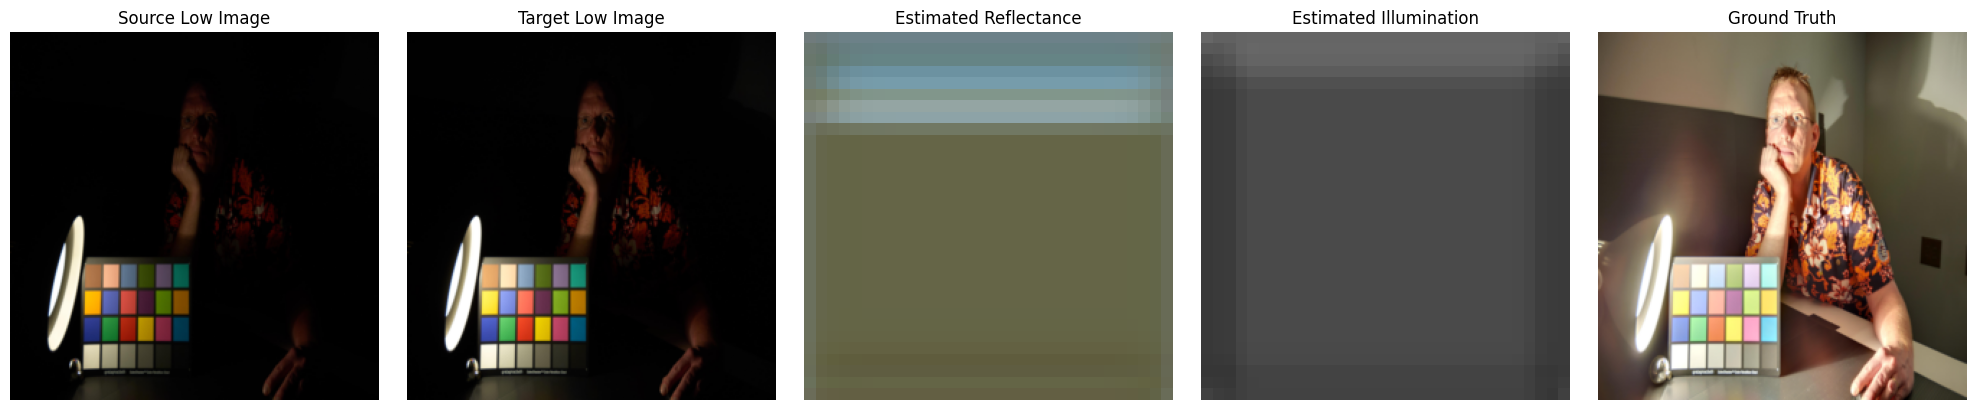

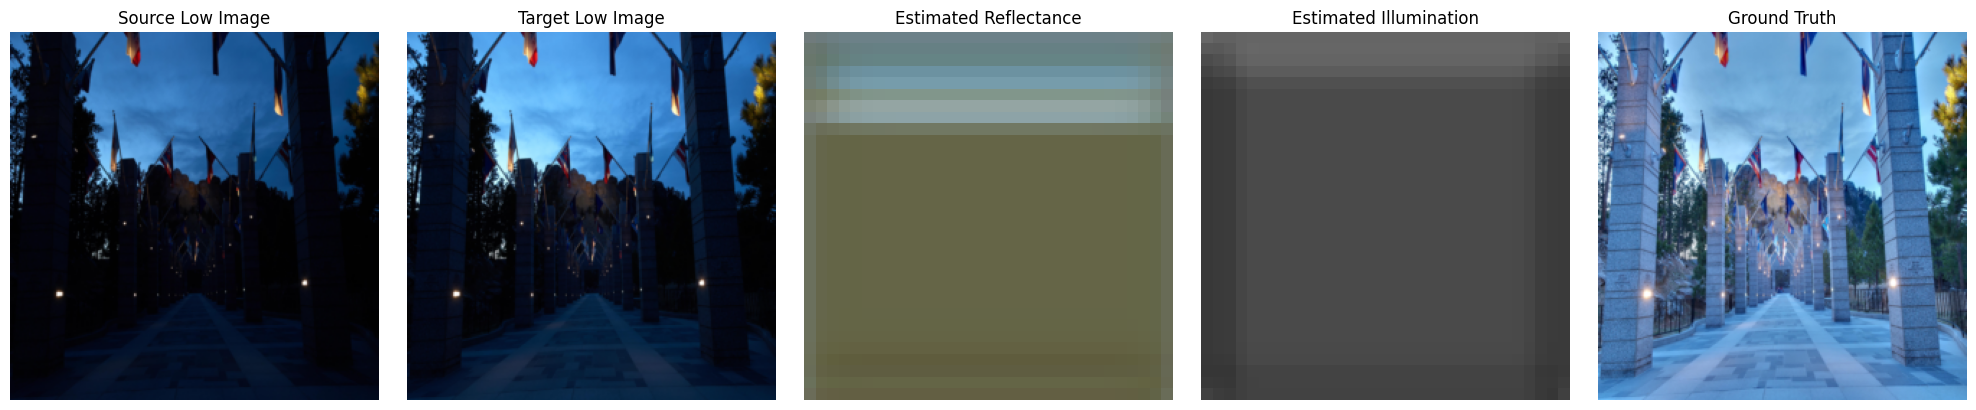

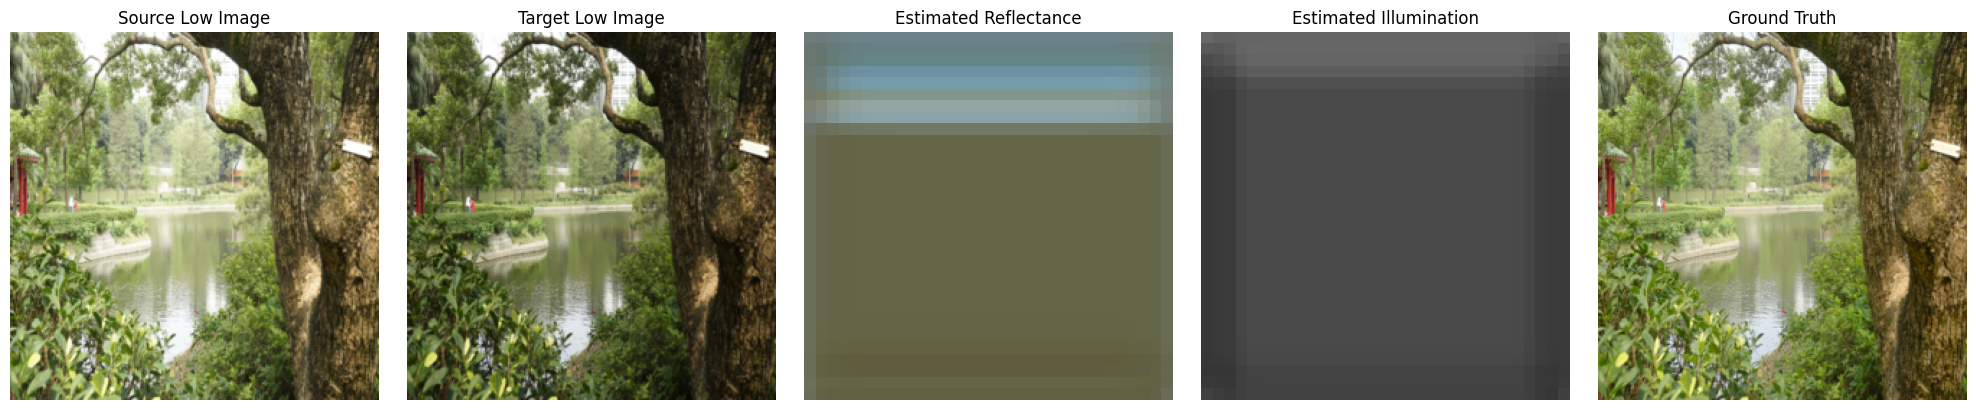

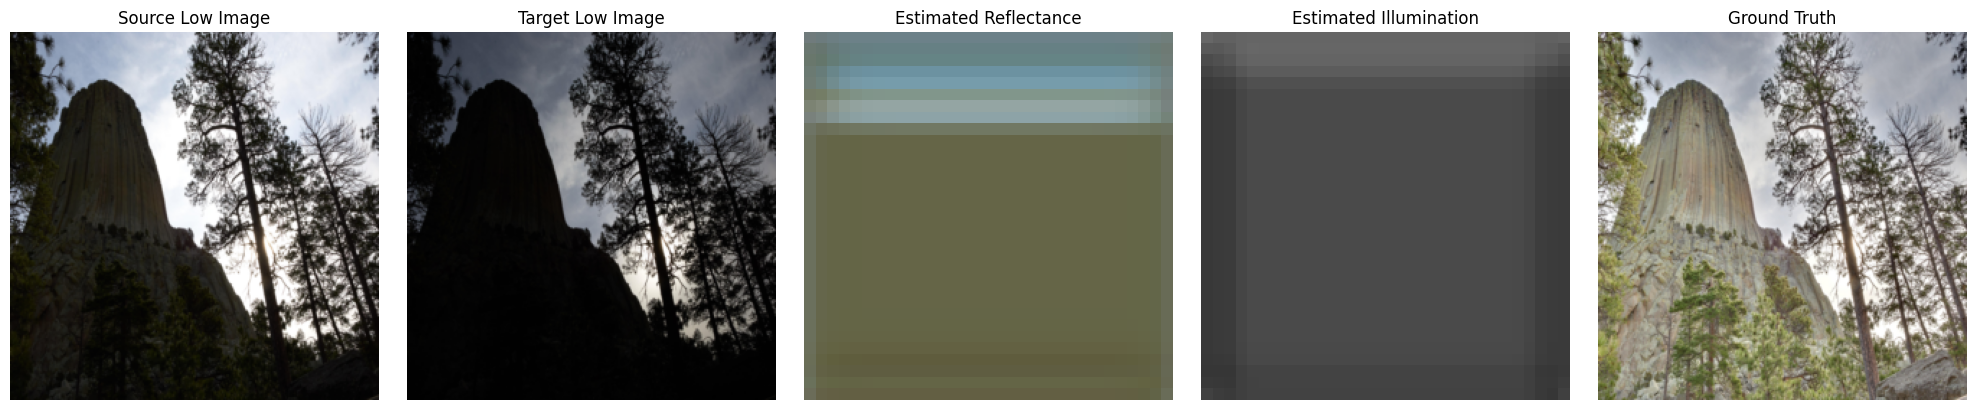

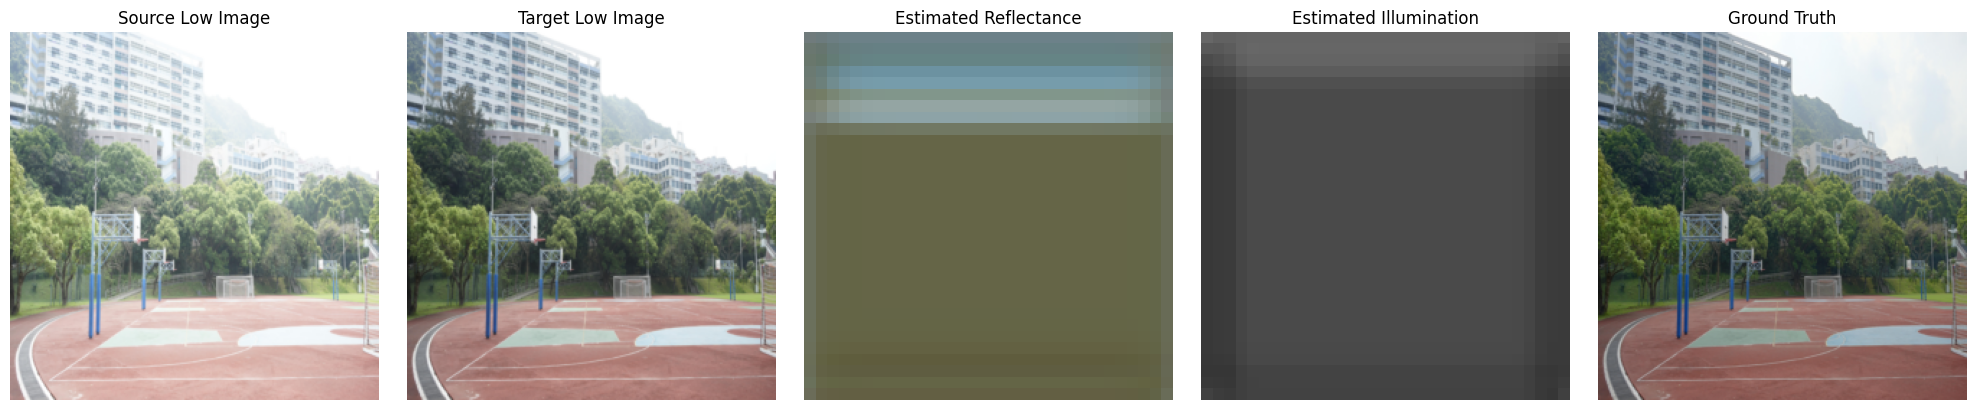

In [52]:
samples_train = [0, 1, 2, 3, 4]
samples_test = [0, 1, 2, 3, 4]
for i in samples_train:
    sample = get_sample(data_arrays_train, i)
    visualize_sample(sample)